# ♟️ World Chess Championship Analysis — Matplotlib & Seaborn
### A data visualization project exploring WCC game patterns, openings, and player performance.
**Dataset:** Synthetically generated World Chess Championship data (1886–2024)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="darkgrid")
print("Libraries loaded successfully!")

Libraries loaded successfully!


In [2]:
np.random.seed(42)

champions = ['Gukesh D', 'Magnus Carlsen', 'Viswanathan Anand',
             'Vladimir Kramnik', 'Garry Kasparov', 'Anatoly Karpov',
             'Bobby Fischer', 'Boris Spassky']

openings = ['Sicilian Defense', 'Queens Gambit', 'Ruy Lopez',
            'French Defense', 'Italian Game', 'Kings Indian',
            'English Opening', 'Caro-Kann']

victory_types = ['Checkmate', 'Resignation', 'Timeout', 'Draw']

n = 500

df = pd.DataFrame({
    'game_id': range(1, n+1),
    'year': np.random.randint(1886, 2025, n),
    'white_player': np.random.choice(champions, n),
    'black_player': np.random.choice(champions, n),
    'white_rating': np.random.randint(2600, 2900, n),
    'black_rating': np.random.randint(2600, 2900, n),
    'winner': np.random.choice(['White', 'Black', 'Draw'], n, p=[0.45, 0.40, 0.15]),
    'opening': np.random.choice(openings, n),
    'victory_type': np.random.choice(victory_types, n, p=[0.40, 0.35, 0.15, 0.10]),
    'num_moves': np.random.randint(20, 120, n),
})

print(df.head())

   game_id  year       white_player    black_player  white_rating  \
0        1  1988      Boris Spassky  Garry Kasparov          2816   
1        2  1978      Bobby Fischer  Magnus Carlsen          2660   
2        3  1900           Gukesh D        Gukesh D          2703   
3        4  1992  Viswanathan Anand  Magnus Carlsen          2641   
4        5  1957   Vladimir Kramnik   Boris Spassky          2624   

   black_rating winner           opening victory_type  num_moves  
0          2884  White  Sicilian Defense  Resignation         60  
1          2784  White      Kings Indian    Checkmate         61  
2          2638  White    French Defense         Draw         69  
3          2822  Black         Ruy Lopez    Checkmate        103  
4          2783  White         Ruy Lopez         Draw         59  


## ⚪🔵 Plot 1 — Win Rate by Color
Does White have an advantage over Black in the World Chess Championship?

/tmp/ipykernel_4034/3238031705.py:10: UserWarning: Glyph 128309 (\N{LARGE BLUE CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128309 (\N{LARGE BLUE CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


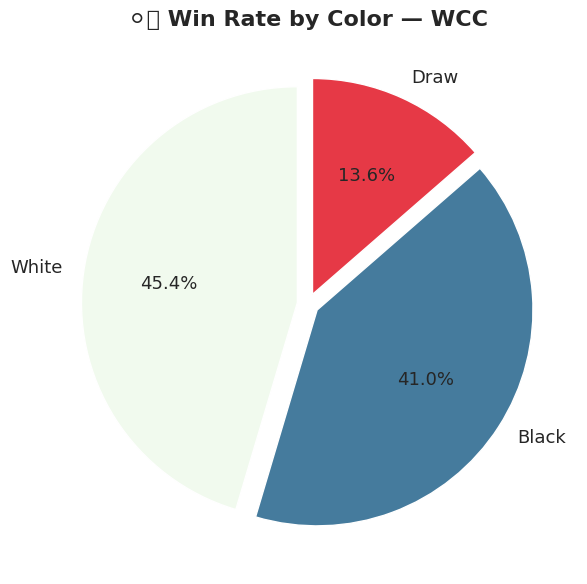

In [3]:
plt.figure(figsize=(8, 6))
win_counts = df['winner'].value_counts()
colors = ['#f1faee', '#457b9d', '#e63946']

plt.pie(win_counts.values, labels=win_counts.index,
        colors=colors, autopct='%1.1f%%',
        startangle=90, explode=[0.05, 0.05, 0.05],
        textprops={'fontsize': 13})
plt.title('⚪🔵 Win Rate by Color — WCC', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

## 🎯 Plot 2 — Most Popular Openings
Which openings are most frequently played in the World Chess Championship?

/tmp/ipykernel_4034/1841596592.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=opening_counts.values, y=opening_counts.index, palette='viridis')
/tmp/ipykernel_4034/1841596592.py:8: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


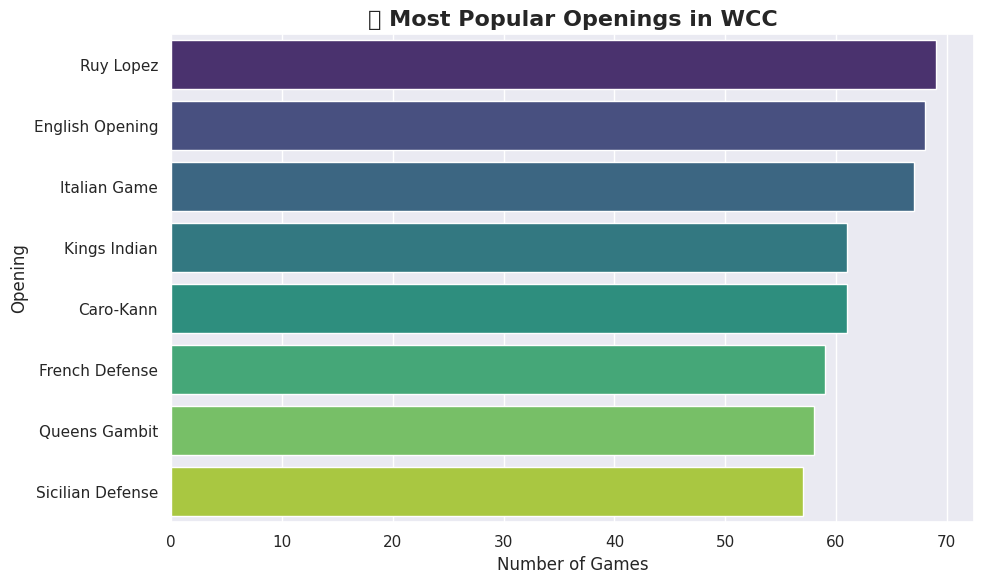

In [4]:
plt.figure(figsize=(10, 6))
opening_counts = df['opening'].value_counts()

sns.barplot(x=opening_counts.values, y=opening_counts.index, palette='viridis')
plt.title('🎯 Most Popular Openings in WCC', fontsize=16, fontweight='bold')
plt.xlabel('Number of Games', fontsize=12)
plt.ylabel('Opening', fontsize=12)
plt.tight_layout()
plt.show()

## ⚔️ Plot 3 — Victory Type Breakdown
How do players win in the World Chess Championship — Checkmate, Resignation or Timeout?

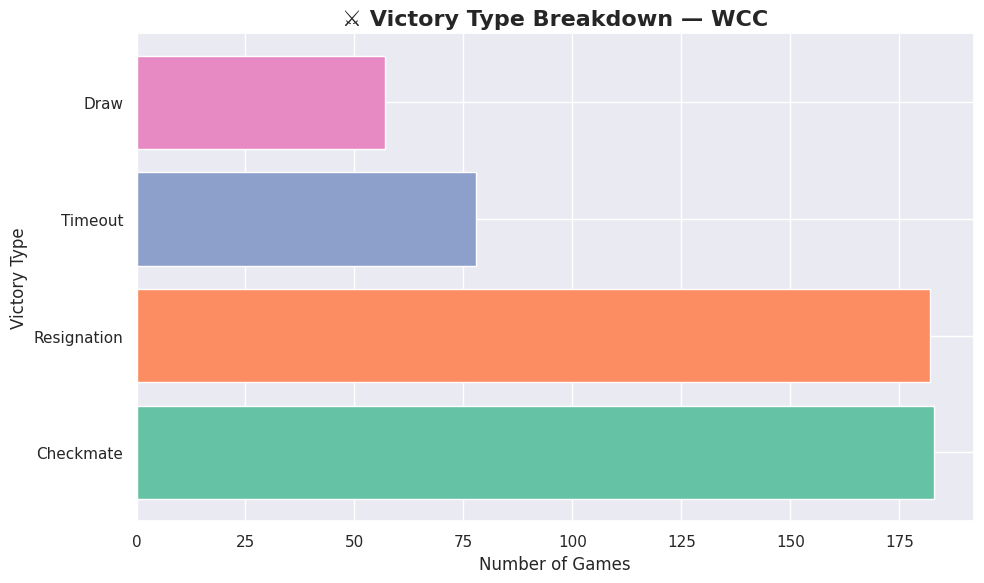

In [5]:
plt.figure(figsize=(10, 6))
victory_counts = df['victory_type'].value_counts()
colors = sns.color_palette('Set2', len(victory_counts))

plt.barh(victory_counts.index, victory_counts.values, color=colors)
plt.title('⚔️ Victory Type Breakdown — WCC', fontsize=16, fontweight='bold')
plt.xlabel('Number of Games', fontsize=12)
plt.ylabel('Victory Type', fontsize=12)
plt.tight_layout()
plt.show()

## 📈 Plot 4 — Game Length Distribution
How many moves do World Chess Championship games typically last?

/tmp/ipykernel_4034/2999784357.py:10: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


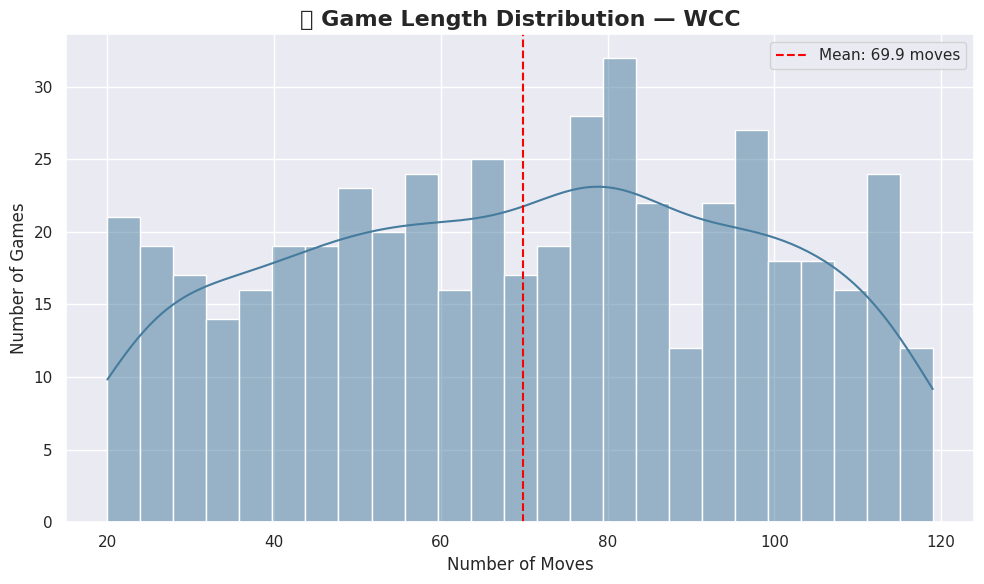

In [6]:
plt.figure(figsize=(10, 6))
sns.histplot(df['num_moves'], bins=25, kde=True,
             color='#457b9d', edgecolor='white')
plt.axvline(df['num_moves'].mean(), color='red', linestyle='--',
            label=f"Mean: {df['num_moves'].mean():.1f} moves")
plt.title('📈 Game Length Distribution — WCC', fontsize=16, fontweight='bold')
plt.xlabel('Number of Moves', fontsize=12)
plt.ylabel('Number of Games', fontsize=12)
plt.legend()
plt.tight_layout()
plt.show()

## 🔥 Plot 5 — Player Performance Heatmap
Which openings do WCC champions perform best with?

/tmp/ipykernel_4034/2476479879.py:14: UserWarning: Glyph 128293 (\N{FIRE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128293 (\N{FIRE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


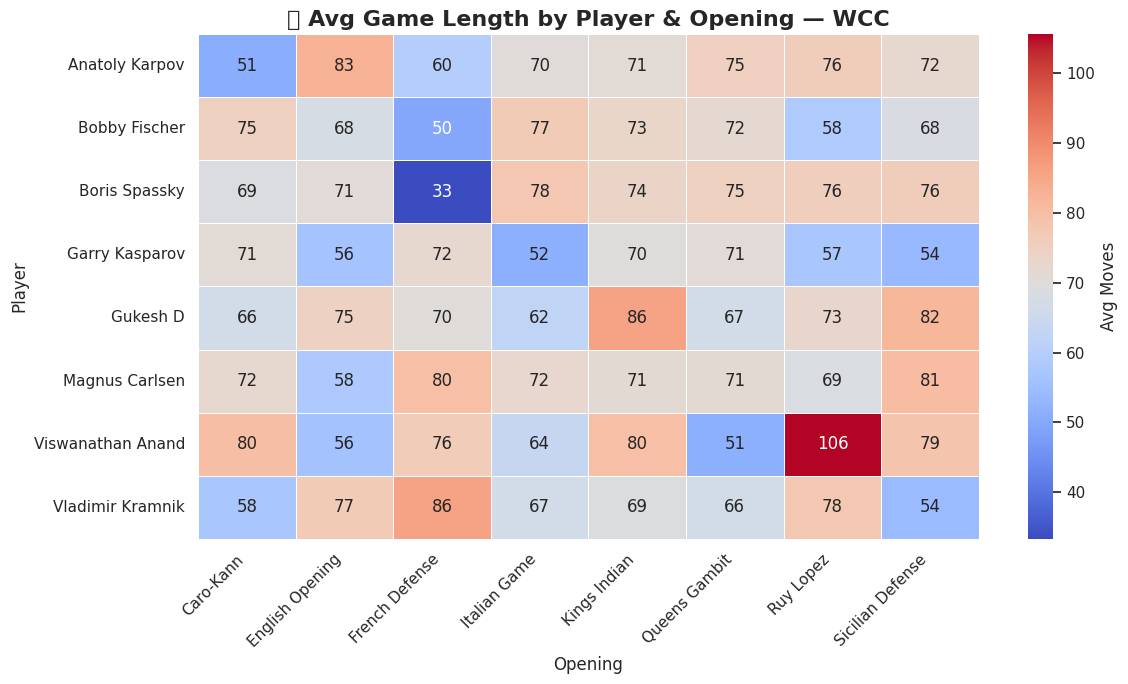

In [7]:
plt.figure(figsize=(12, 7))
heatmap_data = df.pivot_table(values='num_moves',
                               index='white_player',
                               columns='opening',
                               aggfunc='mean')

sns.heatmap(heatmap_data, annot=True, fmt='.0f',
            cmap='coolwarm', linewidths=0.5,
            cbar_kws={'label': 'Avg Moves'})
plt.title('🔥 Avg Game Length by Player & Opening — WCC', fontsize=16, fontweight='bold')
plt.xlabel('Opening', fontsize=12)
plt.ylabel('Player', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()